# Cadenas de Markov de Tiempo Continuo
## Análisis Transitorio

---

**Modelado bajo Incertidumbre**  
Departamento de Ingeniería Industrial · Universidad de los Andes  
*Semana 8 · Módulo 2*

## Agenda

1. Probabilidades de transición $p_{ij}(t)$
2. Ecuaciones de Kolmogorov hacia adelante
3. Solución analítica: exponencial matricial
4. Solución numérica
5. Interpretación del análisis transitorio
6. Solución via ODE (método alternativo)


# Análisis Transitorio
## Ecuaciones de Kolmogorov

## Probabilidades de Transición

Definimos $p_{ij}(t) = P(X(t) = j \mid X(0) = i)$, agrupadas en la **matriz de transición**:

$$P(t) = \{p_{ij}(t)\}$$

Sea $\boldsymbol{\pi}(t)$ el **vector de estado** (fila) con $\pi_j(t) = P(X(t) = j)$.

Si la distribución inicial es $\boldsymbol{\pi}(0)$, entonces:

$$\boldsymbol{\pi}(t) = \boldsymbol{\pi}(0)\, P(t)$$

## Ecuaciones de Kolmogorov hacia Adelante

La dinámica del sistema está gobernada por:

$$\frac{d\,\boldsymbol{\pi}(t)}{dt} = \boldsymbol{\pi}(t)\, Q$$

O equivalentemente para la matriz de transición:

$$\frac{d\,P(t)}{dt} = P(t)\, Q, \quad P(0) = I$$

**Forma expandida** para $\pi_j(t)$:

$$\frac{d\,\pi_j(t)}{dt} = \sum_{i \neq j} \pi_i(t)\, q_{ij} - \pi_j(t)\, \nu_j$$

$$\underbrace{\text{Tasa de cambio}}_{}\; = \underbrace{\text{Flujo de entrada}}_{}\; - \underbrace{\text{Flujo de salida}}_{}$$

## Solución Analítica: Exponencial Matricial

La solución exacta de $\frac{dP}{dt} = PQ$ con $P(0)=I$ es:

$$\boxed{P(t) = e^{Qt}}$$

donde $e^{Qt}$ es la **exponencial matricial**:

$$e^{Qt} = I + Qt + \frac{(Qt)^2}{2!} + \frac{(Qt)^3}{3!} + \cdots = \sum_{k=0}^{\infty} \frac{(Qt)^k}{k!}$$

Entonces: $\boldsymbol{\pi}(t) = \boldsymbol{\pi}(0)\, e^{Qt}$

## Solución Numérica del Análisis Transitorio

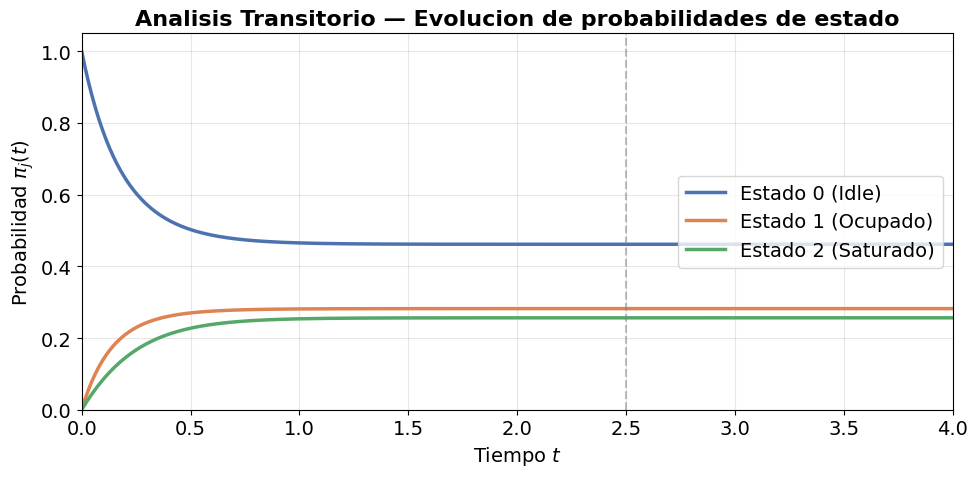

In [6]:
# ============================================================
# ANÁLISIS TRANSITORIO — Exponencial Matricial
# ============================================================

# Distribución inicial: comenzamos en estado 0 (Idle)
pi0 = np.array([1.0, 0.0, 0.0])

# Vector de tiempos
T_max = 4.0
t_vals = np.linspace(0, T_max, 500)

# pi(t) = pi(0) @ expm(Q*t)
pi_t = np.array([pi0 @ expm(Q * t) for t in t_vals])

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ['Estado 0 (Idle)', 'Estado 1 (Ocupado)', 'Estado 2 (Saturado)']

for j in range(3):
    ax.plot(t_vals, pi_t[:, j], color=colors[j], lw=2.5, label=labels[j])

ax.set_xlabel('Tiempo $t$')
ax.set_ylabel('Probabilidad $\\pi_j(t)$')
ax.set_title('Analisis Transitorio — Evolucion de probabilidades de estado', fontweight='bold')
ax.legend(loc='right')
ax.set_xlim(0, T_max)
ax.set_ylim(0, 1.05)
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, label='Aprox. estado estable')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación del Análisis Transitorio

- **Al inicio** ($t=0$): el sistema está en el estado 0 con probabilidad 1.
- **Con el tiempo**: las probabilidades evolucionan siguiendo las ecuaciones de Kolmogorov.
- **A largo plazo**: convergen hacia la **distribución estacionaria** $\boldsymbol{\pi}^*$.

> El análisis transitorio responde: *¿Cómo evoluciona el sistema desde el instante inicial?*

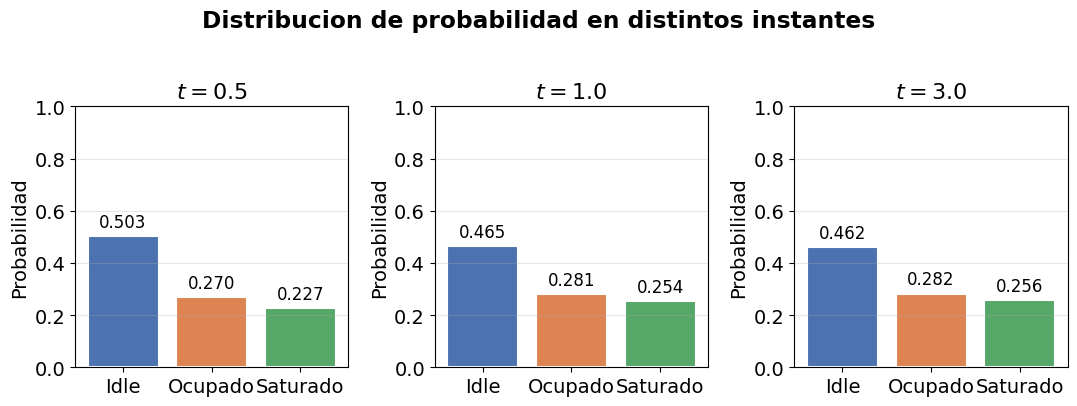

In [7]:
# Distribución en tres instantes distintos
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
tiempos_ejemplo = [0.5, 1.0, 3.0]
for ax, t_ex in zip(axes, tiempos_ejemplo):
    pi_ex = pi0 @ expm(Q * t_ex)
    bars = ax.bar(['Idle', 'Ocupado', 'Saturado'], pi_ex,
                  color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'$t = {t_ex}$', fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probabilidad')
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, pi_ex):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=12)
plt.suptitle('Distribucion de probabilidad en distintos instantes', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Solución via ODE (Método Alternativo)

Podemos resolver $\frac{d\boldsymbol{\pi}}{dt} = \boldsymbol{\pi} Q$ también como un sistema de EDOs:

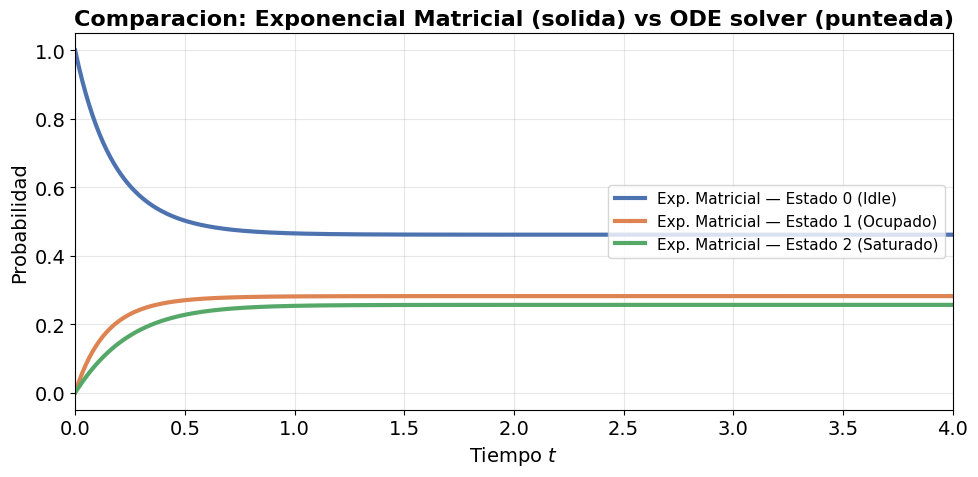

Diferencia maxima entre metodos: 6.536152301617193e-07


In [8]:
# Solución via scipy ODE solver
def kolmogorov_forward(t, pi, Q):
    # d(pi)/dt = pi @ Q  →  trasponer para usar solve_ivp
    return Q.T @ pi

sol = solve_ivp(
    kolmogorov_forward,
    t_span=(0, T_max),
    y0=pi0,
    args=(Q,),
    t_eval=t_vals,
    method='RK45',
    rtol=1e-8
)

pi_ode = sol.y.T  # filas = tiempos, columnas = estados

fig, ax = plt.subplots(figsize=(10, 5))
for j in range(3):
    ax.plot(t_vals, pi_t[:, j], color=colors[j], lw=3, label=f'Exp. Matricial — {labels[j]}')
    ax.plot(t_vals, pi_ode[:, j], '--', color=colors[j], lw=1.5, alpha=0.7)

ax.set_xlabel('Tiempo $t$')
ax.set_ylabel('Probabilidad')
ax.set_title('Comparacion: Exponencial Matricial (solida) vs ODE solver (punteada)', fontweight='bold')
ax.legend(loc='right', fontsize=11)
ax.set_xlim(0, T_max)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Diferencia maxima entre metodos:", np.max(np.abs(pi_t - pi_ode)))